-> Lớp [belly_pain]: Đang tạo 89 mẫu...
-> Lớp [burping]: Đang tạo 95 mẫu...
-> Lớp [discomfort]: Đang tạo 82 mẫu...
-> Lớp [hungry]: Giữ nguyên 267 file.
-> Lớp [tired]: Đang tạo 84 mẫu...


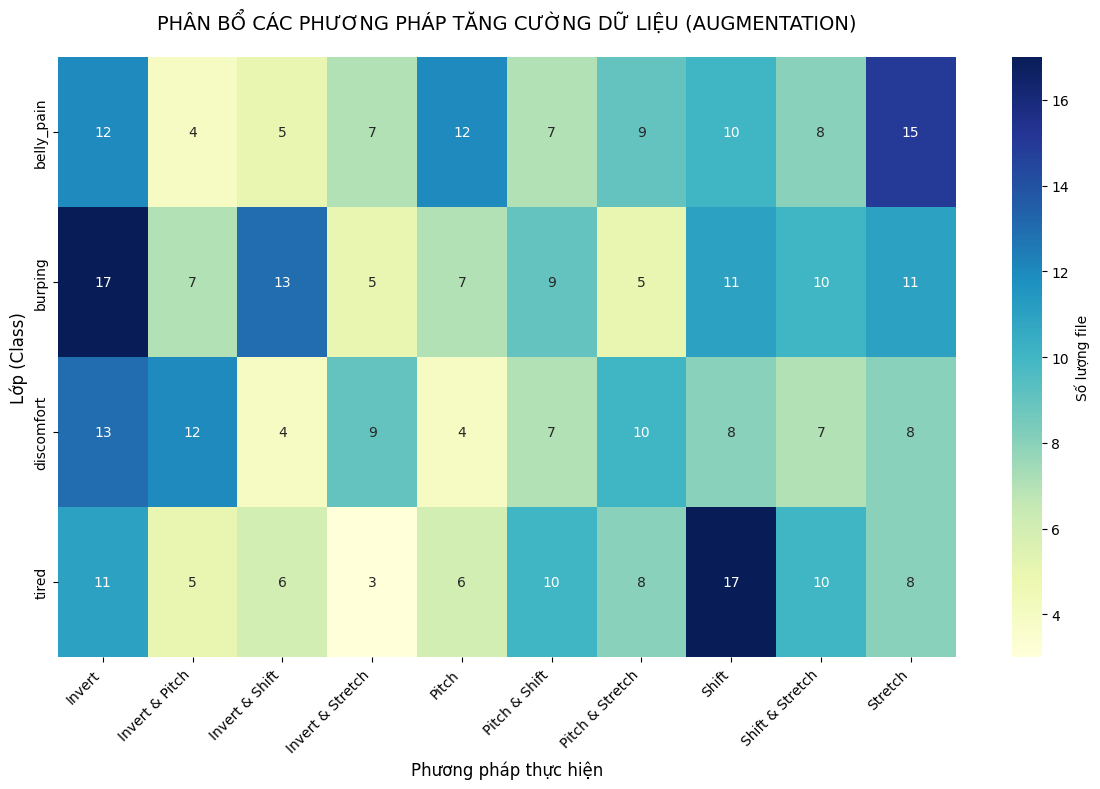


--- BẢNG THỐNG KÊ CHI TIẾT ---
Method      Invert  Invert & Pitch  Invert & Shift  Invert & Stretch  Pitch  \
Class                                                                         
belly_pain      12               4               5                 7     12   
burping         17               7              13                 5      7   
discomfort      13              12               4                 9      4   
tired           11               5               6                 3      6   

Method      Pitch & Shift  Pitch & Stretch  Shift  Shift & Stretch  Stretch  
Class                                                                        
belly_pain              7                9     10                8       15  
burping                 9                5     11               10       11  
discomfort              7               10      8                7        8  
tired                  10                8     17               10        8  

Ảnh biểu đồ đã được lưu 

In [9]:
import librosa
import numpy as np
import soundfile as sf
import os
import random
import glob
import shutil
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
SEED = 69
random.seed(SEED)
np.random.seed(SEED)


class BabyCryVisualAugmenter:
    def __init__(self, sr=16000):
        self.sr = sr
        self.transformations = {
            "stretch": lambda y: librosa.effects.time_stretch(y, rate=random.uniform(0.8, 1.2)),
            "pitch": lambda y: librosa.effects.pitch_shift(y, sr=self.sr, n_steps=random.uniform(-3, 3)),
            "shift": lambda y: np.roll(y, int(random.uniform(-0.2, 0.2) * self.sr)),
            "invert": lambda y: -y
        }
        # Lưu trữ thống kê dưới dạng list các dict để dễ tạo DataFrame
        self.detailed_stats = []

    def _apply_random_aug(self, y):
        num_to_apply = random.randint(1, 2)
        keys = sorted(random.sample(list(self.transformations.keys()), num_to_apply))
        
        method_name = " & ".join(keys).title()
        y_aug = y.copy()
        for key in keys:
            y_aug = self.transformations[key](y_aug)
            
        return y_aug, method_name


    def process_and_visualize(self, root_dir, output_dir, target=250):
        if os.path.exists(output_dir):
            shutil.rmtree(output_dir)
        os.makedirs(output_dir)
        all_classes = sorted(
            [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
        )

        for cls in all_classes:
            src_path = os.path.join(root_dir, cls)
            dst_path = os.path.join(output_dir, cls)
            os.makedirs(dst_path, exist_ok=True)

            orig_files = sorted(glob.glob(os.path.join(src_path, "*.wav")))
            n_orig = len(orig_files)

            # Copy file gốc
            for f in orig_files:
                shutil.copy2(f, os.path.join(dst_path, os.path.basename(f)))

            if cls.lower() == "hungry":
                print(f"-> Lớp [hungry]: Giữ nguyên {n_orig} file.")
                continue

            needed = target - n_orig
            if needed > 0:
                print(f"-> Lớp [{cls}]: Đang tạo {needed} mẫu...")
                for i in range(needed):
                    source_f = random.choice(orig_files)
                    y, _ = librosa.load(source_f, sr=self.sr)
                    y_aug, method = self._apply_random_aug(y)
                    
                    # Lưu thông tin vào danh sách thống kê
                    self.detailed_stats.append({"Class": cls, "Method": method})
                    
                    new_name = f"aug_{i}_{method.replace(' & ', '_')}_{os.path.basename(source_f)}"
                    sf.write(os.path.join(dst_path, new_name), y_aug, self.sr)

        self._draw_heatmap()

    def _draw_heatmap(self):
        if not self.detailed_stats:
            print("Không có dữ liệu augment để vẽ biểu đồ.")
            return

        # 1. Chuyển list thành DataFrame
        df = pd.DataFrame(self.detailed_stats)

        # 2. Tạo bảng xoay (Pivot Table) để đếm số lượng theo hàng (Class) và cột (Method)
        summary_table = df.groupby(['Class', 'Method']).size().unstack(fill_value=0)

        # 3. Vẽ biểu đồ Heatmap
        plt.figure(figsize=(12, 8))
        sns.heatmap(summary_table, annot=True, fmt="d", cmap="YlGnBu", cbar_kws={'label': 'Số lượng file'})
        
        plt.title("PHÂN BỔ CÁC PHƯƠNG PHÁP TĂNG CƯỜNG DỮ LIỆU (AUGMENTATION)", fontsize=14, pad=20)
        plt.xlabel("Phương pháp thực hiện", fontsize=12)
        plt.ylabel("Lớp (Class)", fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        
        # Lưu ảnh biểu đồ
        plt.savefig("augmentation_stats.png")
        plt.show()

        print("\n--- BẢNG THỐNG KÊ CHI TIẾT ---")
        print(summary_table)
        print(f"\nẢnh biểu đồ đã được lưu tại: {os.getcwd()}\\augmentation_stats.png")

# --- THỰC THI ---
INPUT = r"C:\Users\Hoannd\Downloads\ail\git_project\-the-adults-cried\official_project_v1\ail\data\corpus\donatecry_copus_split_data\train"
OUTPUT = r"C:\Users\Hoannd\Downloads\ail\git_project\-the-adults-cried\official_project_v1\ail\data\corpus\donatecry_copus_split_data\train_augumentation"

augmenter = BabyCryVisualAugmenter(sr=16000)
augmenter.process_and_visualize(INPUT, OUTPUT, target=100)